In [ ]:
pip install torch torchvision matplotlib


  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl (176.2 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (99 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
latent_dim = 100
num_classes = 10
image_size = 28
channels = 1
batch_size = 64
epochs = 30
sample_interval = 100

# Data Preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Load Fashion MNIST dataset
dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
subset_indices = list(range(5000))  # Use only 5000 images
subset = Subset(dataset, subset_indices)
dataloader = DataLoader(subset, batch_size=batch_size, shuffle=True)

# Generator architecture
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.init_size = image_size // 4
        self.l1 = nn.Sequential(nn.Linear(latent_dim + num_classes, 128 * self.init_size ** 2))

        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, channels, 3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        gen_input = torch.cat((self.label_emb(labels), noise), -1)
        out = self.l1(gen_input)
        out = out.view(out.shape[0], 128, self.init_size, self.init_size)
        img = self.conv_blocks(out)
        return img

# Discriminator architecture
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)

        self.model = nn.Sequential(
            nn.Linear(num_classes + int(np.prod((channels, image_size, image_size))), 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 512),
            nn.Dropout(0.4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1)
        )

    def forward(self, img, labels):
        d_in = torch.cat((img.view(img.size(0), -1), self.label_emb(labels)), -1)
        validity = self.model(d_in)
        return validity

# Initialize generator and discriminator
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# Loss function
adversarial_loss = nn.MSELoss().to(device)

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

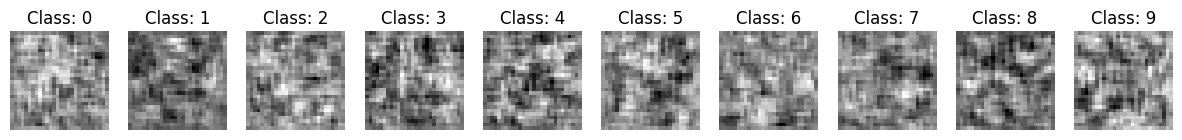

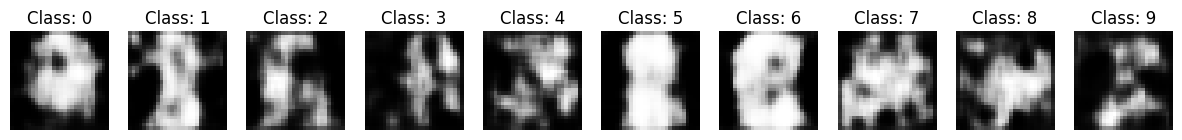

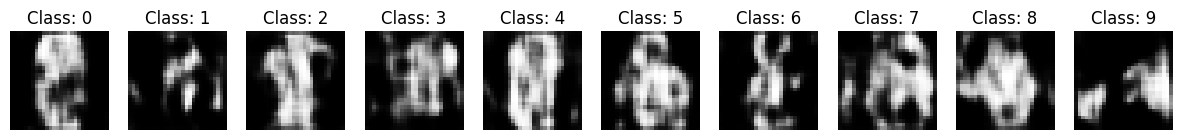

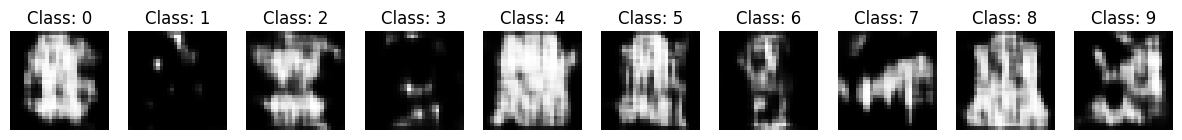

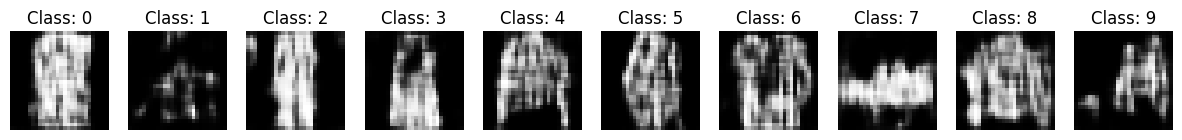

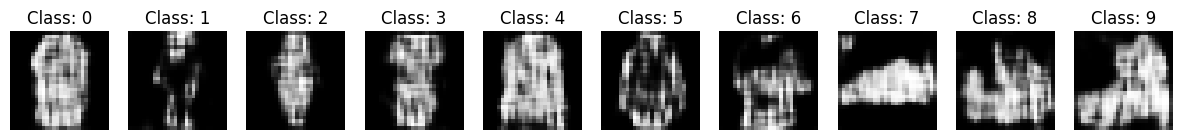

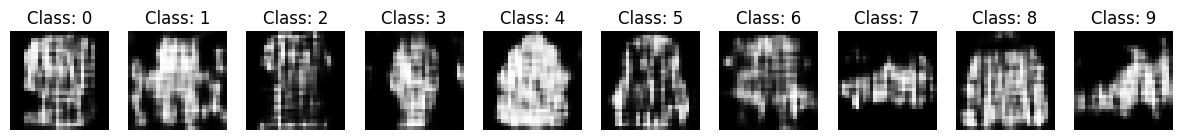

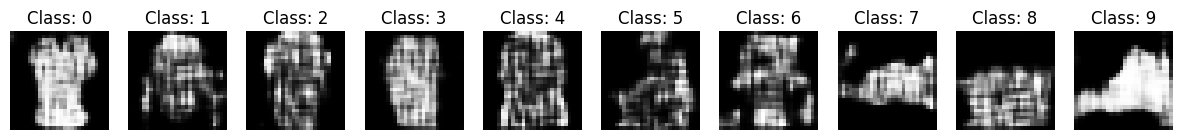

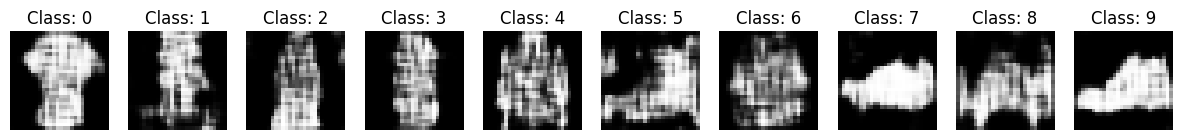

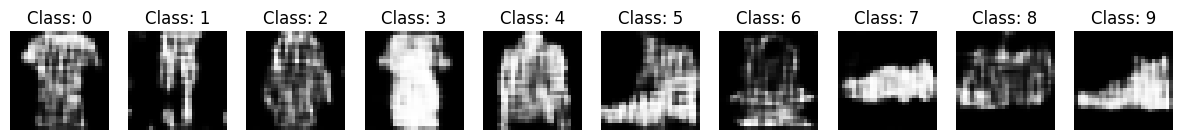

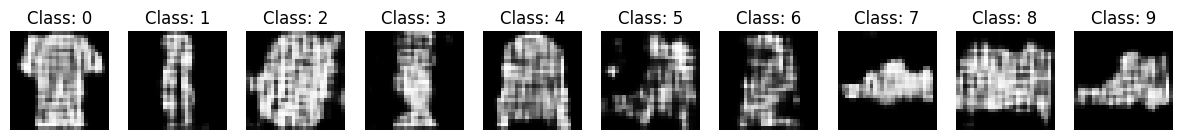

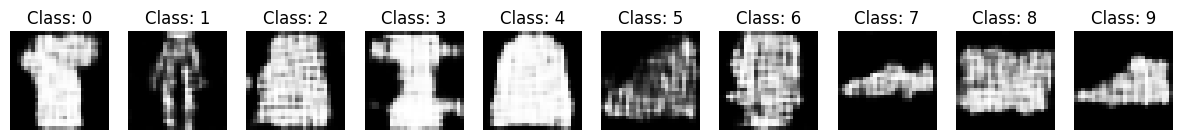

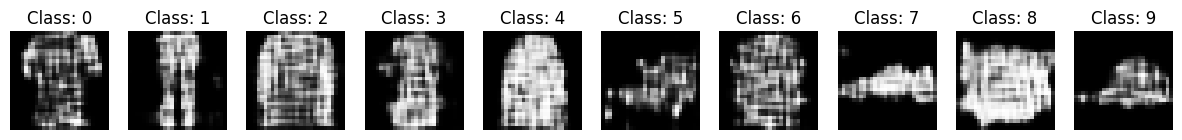

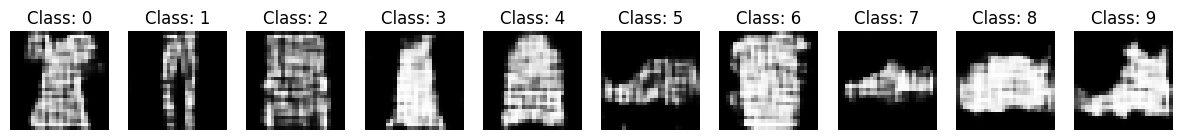

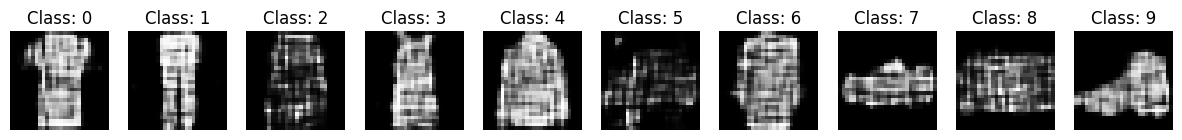

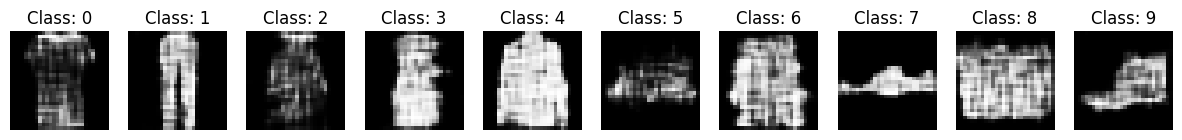

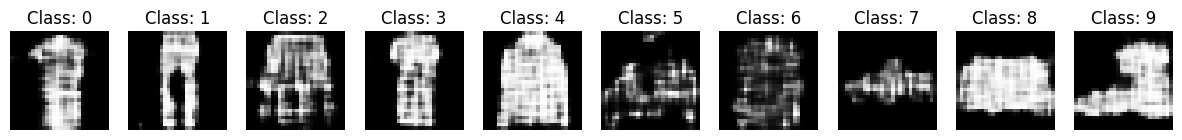

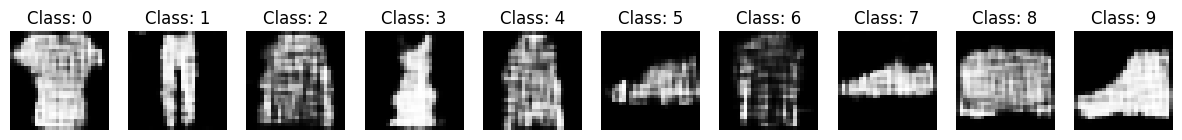

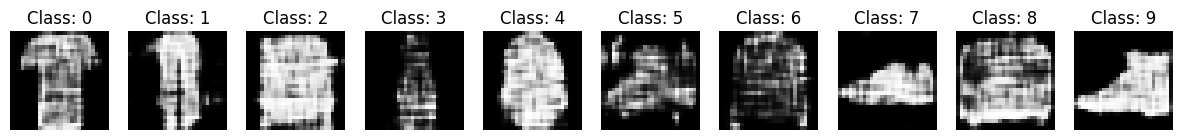

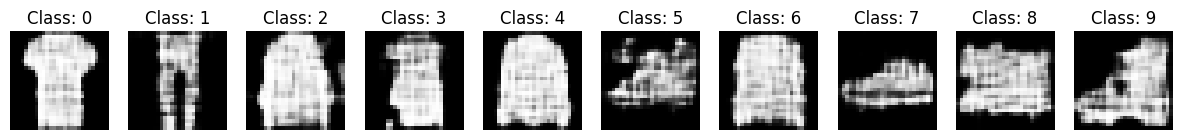

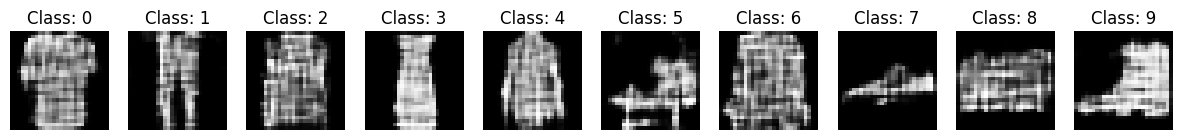

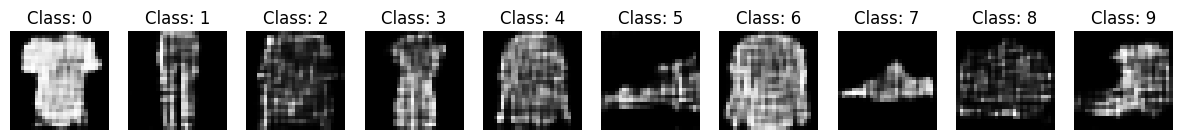

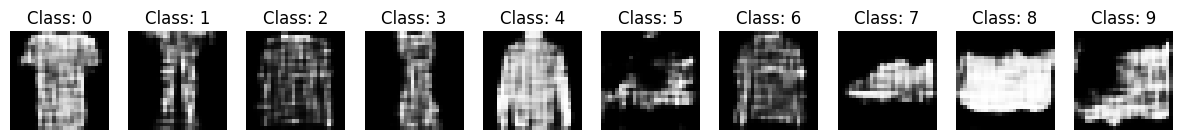

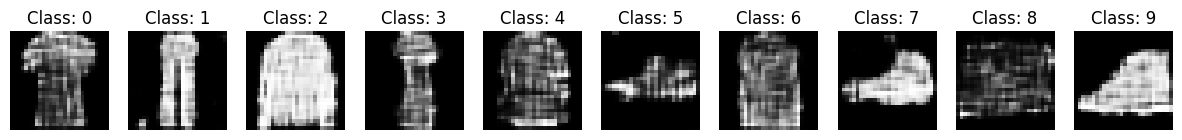

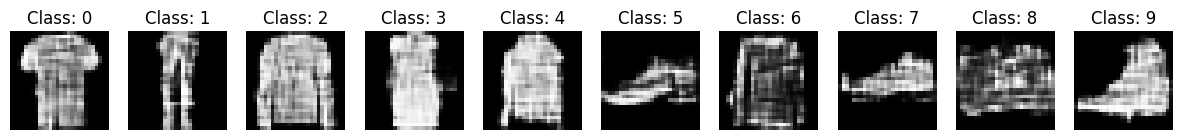

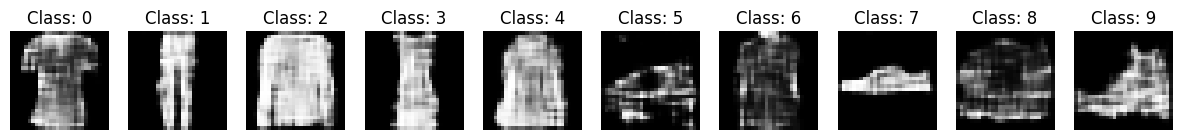

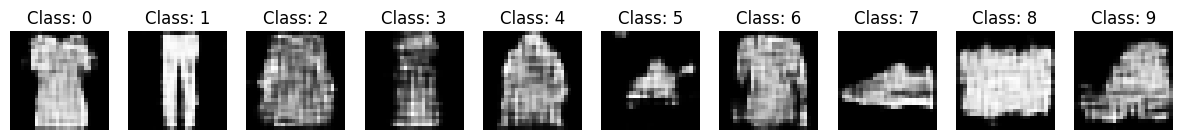

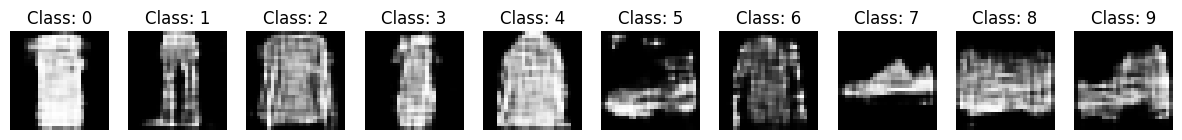

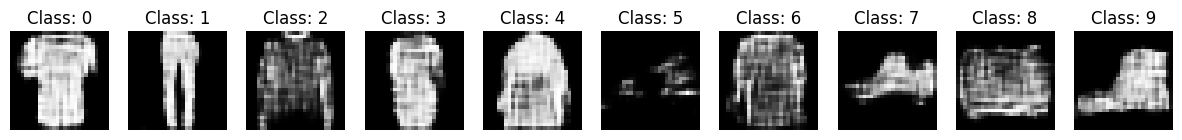

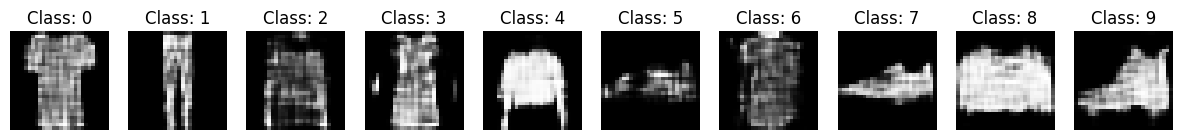

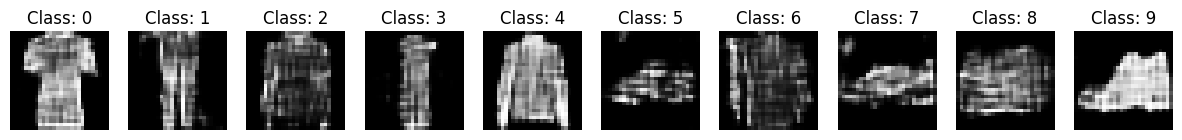

In [6]:
# Training Loop
for epoch in range(epochs):
    for i, (imgs, labels) in enumerate(dataloader):
        batch_size = imgs.size(0)

        # Adversarial ground truths
        valid = torch.ones((batch_size, 1), requires_grad=False).to(device)
        fake = torch.zeros((batch_size, 1), requires_grad=False).to(device)

        # Configure input
        real_imgs = imgs.to(device)
        labels = labels.to(device)

        # -----------------
        #  Train Generator
        # -----------------
        optimizer_G.zero_grad()

        # Sample noise as generator input
        z = torch.randn((batch_size, latent_dim)).to(device)

        # Generate a batch of images
        gen_imgs = generator(z, labels)

        # Loss measures generator's ability to fool the discriminator
        validity = discriminator(gen_imgs, labels)
        g_loss = adversarial_loss(validity, valid)

        g_loss.backward()
        optimizer_G.step()

        # ---------------------
        #  Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()

        # Loss for real images
        real_pred = discriminator(real_imgs, labels)
        d_real_loss = adversarial_loss(real_pred, valid)

        # Loss for fake images
        fake_pred = discriminator(gen_imgs.detach(), labels)
        d_fake_loss = adversarial_loss(fake_pred, fake)

        # Total discriminator loss
        d_loss = (d_real_loss + d_fake_loss) / 2

        d_loss.backward()
        optimizer_D.step()

        # Print progress
        #print(f"[Epoch {epoch}/{epochs}] [Batch {i}/{len(dataloader)}] [D loss: {d_loss.item()}] [G loss: {g_loss.item()}]")

        # Save generated samples at sample interval
        if i % sample_interval == 0:
            generator.eval()
            sample_labels = torch.arange(0, 10).long().to(device)
            sample_z = torch.randn((10, latent_dim)).to(device)
            gen_imgs = generator(sample_z, sample_labels)
            gen_imgs = gen_imgs * 0.5 + 0.5  # Rescale images to [0, 1]
            fig, axs = plt.subplots(1, 10, figsize=(15, 15))
            for j in range(10):
                axs[j].imshow(gen_imgs[j].detach().cpu().numpy().squeeze(), cmap='gray')
                axs[j].set_title(f"Class: {sample_labels[j].item()}")
                axs[j].axis('off')
            plt.show()
            generator.train()

# Generate conditional samples for different fashion categories and visualize the results
generator.eval()
sample_labels = torch.arange(0, 10).long().to(device)
sample_z = torch.randn((10, latent_dim)).to(device)
gen_imgs = generator(sample_z, sample_labels)
gen_imgs = gen_imgs * 0.5 + 0.5  # Rescale images to [0, 1]
fig, axs = plt.subplots(1, 10, figsize=(15, 15))
for j in range(10):
    axs[j].imshow(gen_imgs[j].detach().cpu().numpy().squeeze(), cmap='gray')
    axs[j].set_title(f"Class: {sample_labels[j].item()}")
    axs[j].axis('off')
plt.show()




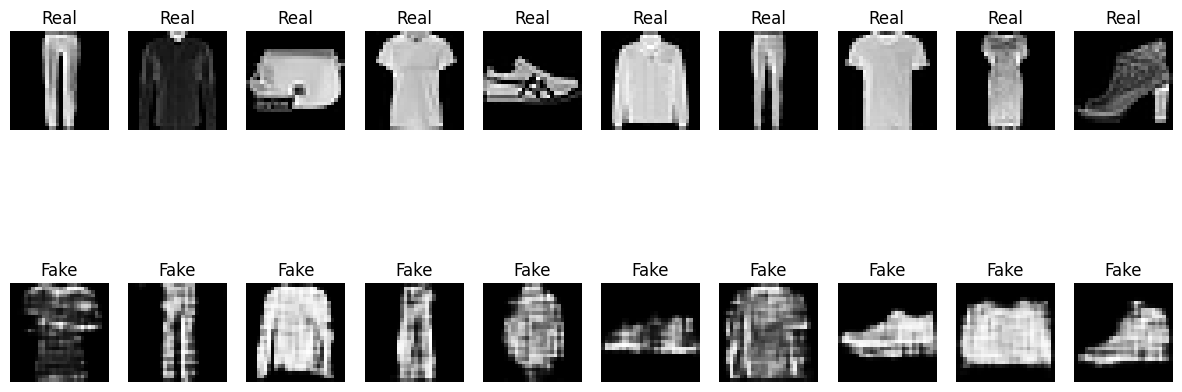

In [2]:
# Real vs Fake visual analysis
real_imgs, _ = next(iter(dataloader))
real_imgs = real_imgs[:10] * 0.5 + 0.5  # Rescale images to [0, 1]
fig, axs = plt.subplots(2, 10, figsize=(15, 6))
for i in range(10):
    axs[0, i].imshow(real_imgs[i].cpu().numpy().squeeze(), cmap='gray')
    axs[0, i].set_title("Real")
    axs[0, i].axis('off')
    axs[1, i].imshow(gen_imgs[i].detach().cpu().numpy().squeeze(), cmap='gray')
    axs[1, i].set_title("Fake")
    axs[1, i].axis('off')
plt.show()